# Principal Component Analysis with Cancer Data

In [0]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/drive


# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [29]:
cancer_df = pd.read_csv('/content/drive/My Drive/Machine Learning/Assignments/Internal/Residency 5 internal assignment/breast-cancer-wisconsin-data.csv')
cancer_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [39]:
cancer_df.drop_duplicates(inplace=True)
cancer_df.shape

(691, 11)

In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [40]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null object
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: int64(10), object(1)
memory usage: 64.8+ KB


In [41]:
cancer_df.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.910000e+02,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,1.073333e+06,4.426918,3.130246,3.201158,2.824891,3.211288,3.435601,2.882779,1.593343,2.688857
std,6.192953e+05,2.815861,3.041328,2.959886,2.866552,2.199852,2.442345,3.066298,1.723129,0.951051
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.725490e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238437e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [42]:
cancer_df.shape

(691, 11)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [0]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [43]:
cancer_df.isnull().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [44]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?

temp = pd.DataFrame(cancer_df['Bare Nuclei'].str.isdigit()) 
temp[temp['Bare Nuclei'] == False]

,Bare Nuclei
23,False
40,False
139,False
145,False
158,False
164,False
235,False
249,False
275,False
292,False


In [0]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

cancer_df = cancer_df.replace('?', np.nan)

In [0]:
cancer_df['Bare Nuclei'] = cancer_df['Bare Nuclei'].astype('float64')

In [47]:
cancer_df = cancer_df.apply(lambda x: x.fillna(x.median()),axis=0) 

cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 691 entries, 0 to 698
Data columns (total 11 columns):
ID                             691 non-null int64
ClumpThickness                 691 non-null int64
Cell Size                      691 non-null int64
Cell Shape                     691 non-null int64
Marginal Adhesion              691 non-null int64
Single Epithelial Cell Size    691 non-null int64
Bare Nuclei                    691 non-null float64
Normal Nucleoli                691 non-null int64
Bland Chromatin                691 non-null int64
Mitoses                        691 non-null int64
Class                          691 non-null int64
dtypes: float64(1), int64(10)
memory usage: 64.8 KB


In [48]:
cancer_df = cancer_df.drop('ID', axis=1)
cancer_df.head(10)

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2
5,8,10,10,8,7,10.0,9,7,1,4
6,1,1,1,1,2,10.0,3,1,1,2
7,2,1,2,1,2,1.0,3,1,1,2
8,2,1,1,1,2,1.0,1,1,5,2
9,4,2,1,1,2,1.0,2,1,1,2


# Q4. Perform bi variate analysis including correlation, pairplots and state the inferences. 


In [49]:
# Check for correlation of variable

cancer_df.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.643340,0.653752,0.487949,0.517448,0.590841,0.561076,0.535712,0.350354,0.716938
Cell Size,0.643340,1.000000,0.905420,0.713117,0.747111,0.684791,0.759525,0.727239,0.460064,0.817720
Cell Shape,0.653752,0.905420,1.000000,0.690989,0.714393,0.704382,0.738455,0.724693,0.440592,0.817693
Marginal Adhesion,0.487949,0.713117,0.690989,1.000000,0.608477,0.672719,0.669813,0.602453,0.417167,0.701371
Single Epithelial Cell Size,0.517448,0.747111,0.714393,0.608477,1.000000,0.580709,0.620518,0.634058,0.482644,0.681233
Bare Nuclei,0.590841,0.684791,0.704382,0.672719,0.580709,1.000000,0.672687,0.578417,0.343020,0.816787
Normal Nucleoli,0.561076,0.759525,0.738455,0.669813,0.620518,0.672687,1.000000,0.669059,0.343821,0.756618
Bland Chromatin,0.535712,0.727239,0.724693,0.602453,0.634058,0.578417,0.669059,1.000000,0.427644,0.715540
Mitoses,0.350354,0.460064,0.440592,0.417167,0.482644,0.343020,0.343821,0.427644,1.000000,0.424111
Class,0.716938,0.817720,0.817693,0.701371,0.681233,0.816787,0.756618,0.715540,0.424111,1.000000


In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

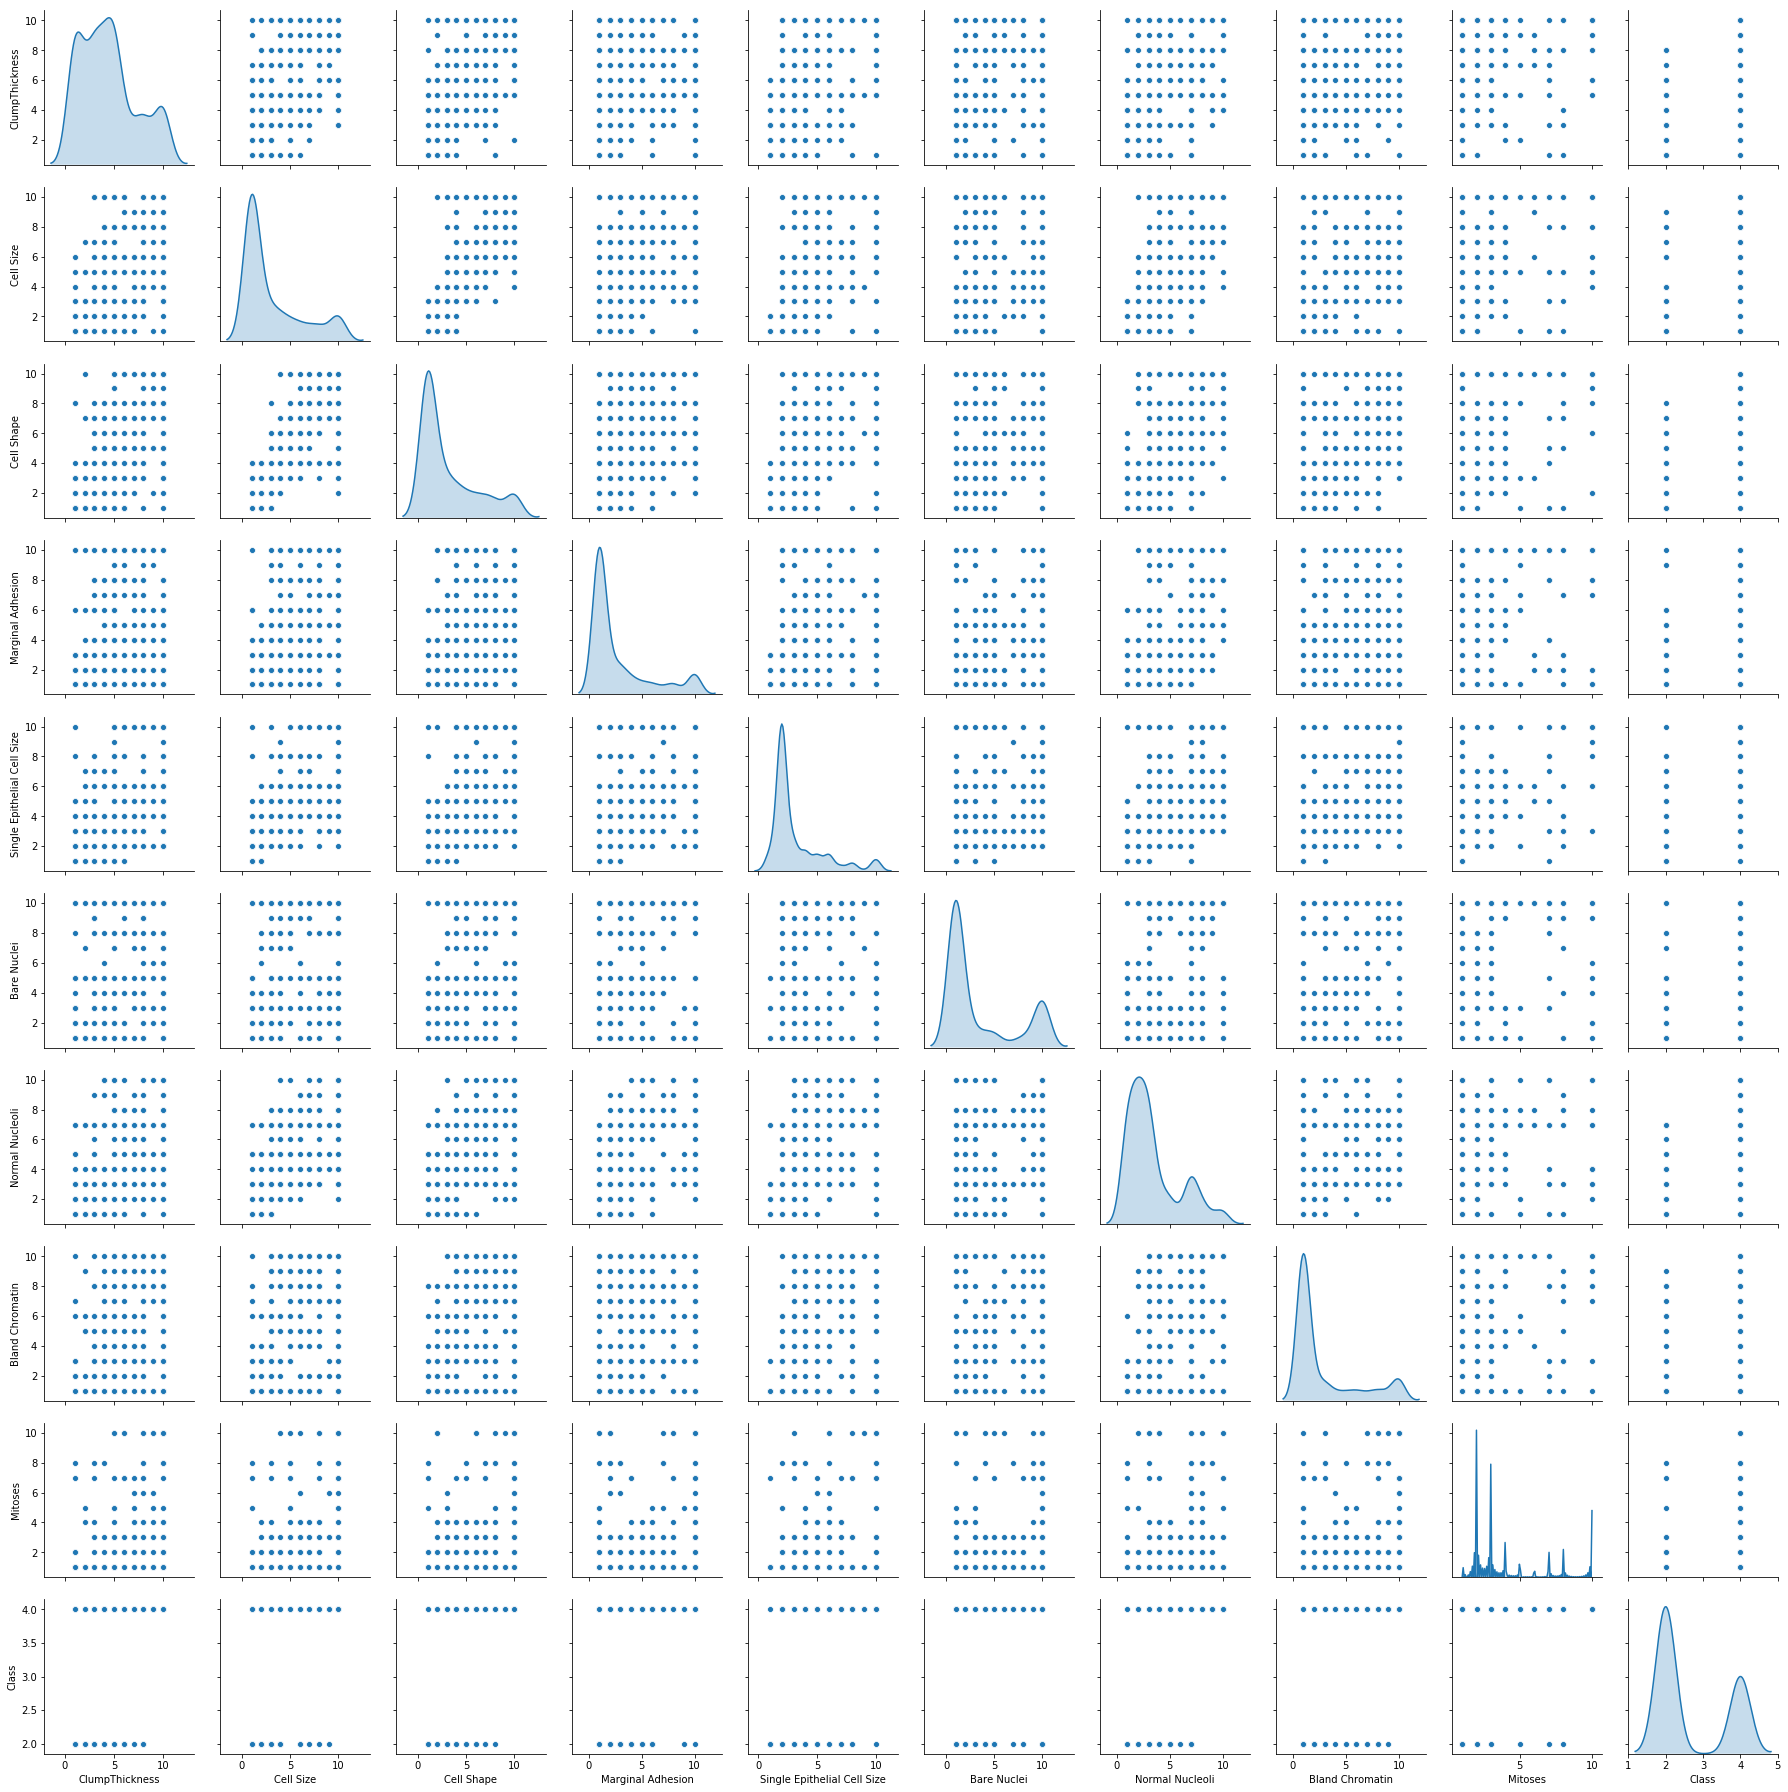

In [50]:
#Let us check for pair plots

sns.pairplot(cancer_df, diag_kind='kde')

In [0]:
# Relationship between variables shows come correlation. 
# Distribution of variables shows most of the values are concentrated on lower side, though range remains same for all that is 
# Between 1 to 10

# Q5 Remove any unwanted columns or outliers, standardize variables in pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [0]:
X = cancer_df.drop("Class", axis=1)
y = cancer_df["Class"]

In [0]:
#from sklearn.model_selection import train_test_split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)


In [55]:
sc = StandardScaler()
X_std =  sc.fit_transform(X)          


/usr/local/lib/python2.7/dist-packages/sklearn/preprocessing/data.py:645: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/usr/local/lib/python2.7/dist-packages/sklearn/base.py:464: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q6 Create a covariance matrix for identifying Principal components

In [56]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

('Covariance Matrix \n%s', array([[1.00144928, 0.64427196, 0.65469961, 0.48865637, 0.51819771,
        0.59169728, 0.56188952, 0.53648819, 0.35086138],
       [0.64427196, 1.00144928, 0.90673173, 0.71415051, 0.74819397,
        0.68578334, 0.760626  , 0.72829333, 0.46073106],
       [0.65469961, 0.90673173, 1.00144928, 0.69199047, 0.71542879,
        0.7054026 , 0.73952487, 0.72574349, 0.44123095],
       [0.48865637, 0.71415051, 0.69199047, 1.00144928, 0.60935911,
        0.67369366, 0.67078345, 0.6033266 , 0.41777184],
       [0.51819771, 0.74819397, 0.71542879, 0.60935911, 1.00144928,
        0.58155073, 0.62141694, 0.63497707, 0.48334351],
       [0.59169728, 0.68578334, 0.7054026 , 0.67369366, 0.58155073,
        1.00144928, 0.67366165, 0.57925498, 0.34351675],
       [0.56188952, 0.760626  , 0.73952487, 0.67078345, 0.62141694,
        0.67366165, 1.00144928, 0.67002891, 0.34431924],
       [0.53648819, 0.72829333, 0.72574349, 0.6033266 , 0.63497707,
        0.57925498, 0.67002891

# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [57]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

('Eigen Vectors \n%s', array([[-0.30205422,  0.14897227, -0.86876767, -0.00255044, -0.02886788,
         0.26683317, -0.19324853, -0.14973061, -0.00303072],
       [-0.38087763,  0.04836887,  0.03660386, -0.73666757,  0.1895303 ,
        -0.44033376, -0.23370998,  0.09452526,  0.12329959],
       [-0.3772005 ,  0.08333656, -0.02037545,  0.66434556,  0.16758725,
        -0.58989507, -0.15107072,  0.06055041,  0.08033821],
       [-0.33432944,  0.05023264,  0.39016444,  0.04590585, -0.48698947,
         0.19616967, -0.4894843 , -0.46460377, -0.01649364],
       [-0.33590135, -0.1737774 ,  0.15769698,  0.06655255,  0.32869726,
         0.39056782,  0.2106072 , -0.06514068,  0.72006271],
       [-0.33287375,  0.2470288 , -0.02956386, -0.07104864, -0.55678398,
        -0.15832954,  0.69557935,  0.0163597 ,  0.05545258],
       [-0.34640353,  0.22999253,  0.18339467,  0.06246875,  0.00969919,
         0.39437394, -0.13201328,  0.73915875, -0.26488494],
       [-0.33648572, -0.02063119,  0.13

# Q8 Find variance and cumulative variance by each eigen vector

In [63]:
tot = sum(eigenvalues)
var_exp = [( i /tot ) * 100 for i in sorted(eigenvalues, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

('Cumulative Variance Explained', array([ 65.56656208,  74.18615308,  80.18441065,  85.35621906,
        89.46893543,  92.8164231 ,  96.07406488,  98.99695992,
       100.        ]))


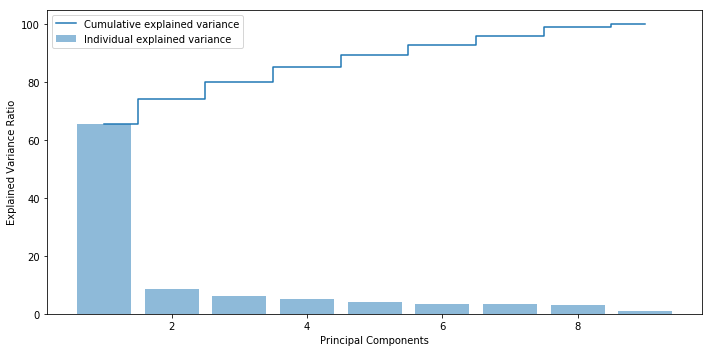

In [65]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, eigenvalues.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, eigenvalues.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [0]:
pca = PCA(n_components=9)
pca_components = pca.fit(X_std)

In [77]:
X_pca = pca.transform(X_std)
X_pca.shape

(691, 9)

In [74]:
pca.components_

array([[ 0.30205422,  0.38087763,  0.3772005 ,  0.33432944,  0.33590135,
         0.33287375,  0.34640353,  0.33648572,  0.22975288],
       [-0.14897227, -0.04836887, -0.08333656, -0.05023264,  0.1737774 ,
        -0.2470288 , -0.22999253,  0.02063119,  0.90634176],
       [-0.86876767,  0.03660386, -0.02037545,  0.39016444,  0.15769698,
        -0.02956386,  0.18339467,  0.13579984, -0.11593909],
       [-0.02886788,  0.1895303 ,  0.16758725, -0.48698947,  0.32869726,
        -0.55678398,  0.00969919,  0.47669866, -0.22937896],
       [-0.00303072,  0.12329959,  0.08033821, -0.01649364,  0.72006271,
         0.05545258, -0.26488494, -0.59954057, -0.163962  ],
       [ 0.19324853,  0.23370998,  0.15107072,  0.4894843 , -0.2106072 ,
        -0.69557935,  0.13201328, -0.31537662, -0.0232693 ],
       [-0.14973061,  0.09452526,  0.06055041, -0.46460377, -0.06514068,
         0.0163597 ,  0.73915875, -0.40981256,  0.17409698],
       [-0.26683317,  0.44033376,  0.58989507, -0.19616967, -0

In [75]:
pca.explained_variance_ratio_

array([0.65566562, 0.08619591, 0.05998258, 0.05171808, 0.04112716,
       0.03347488, 0.03257642, 0.02922895, 0.0100304 ])

# Q10 Find correlation between components and features

In [0]:

df = pd.DataFrame(X_pca)
df_final = df.join(y)

/usr/local/lib/python2.7/dist-packages/statsmodels/nonparametric/kde.py:448: RuntimeWarning: invalid value encountered in greater
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.
/usr/local/lib/python2.7/dist-packages/statsmodels/nonparametric/kde.py:448: RuntimeWarning: invalid value encountered in less
  X = X[np.logical_and(X > clip[0], X < clip[1])] # won't work for two columns.


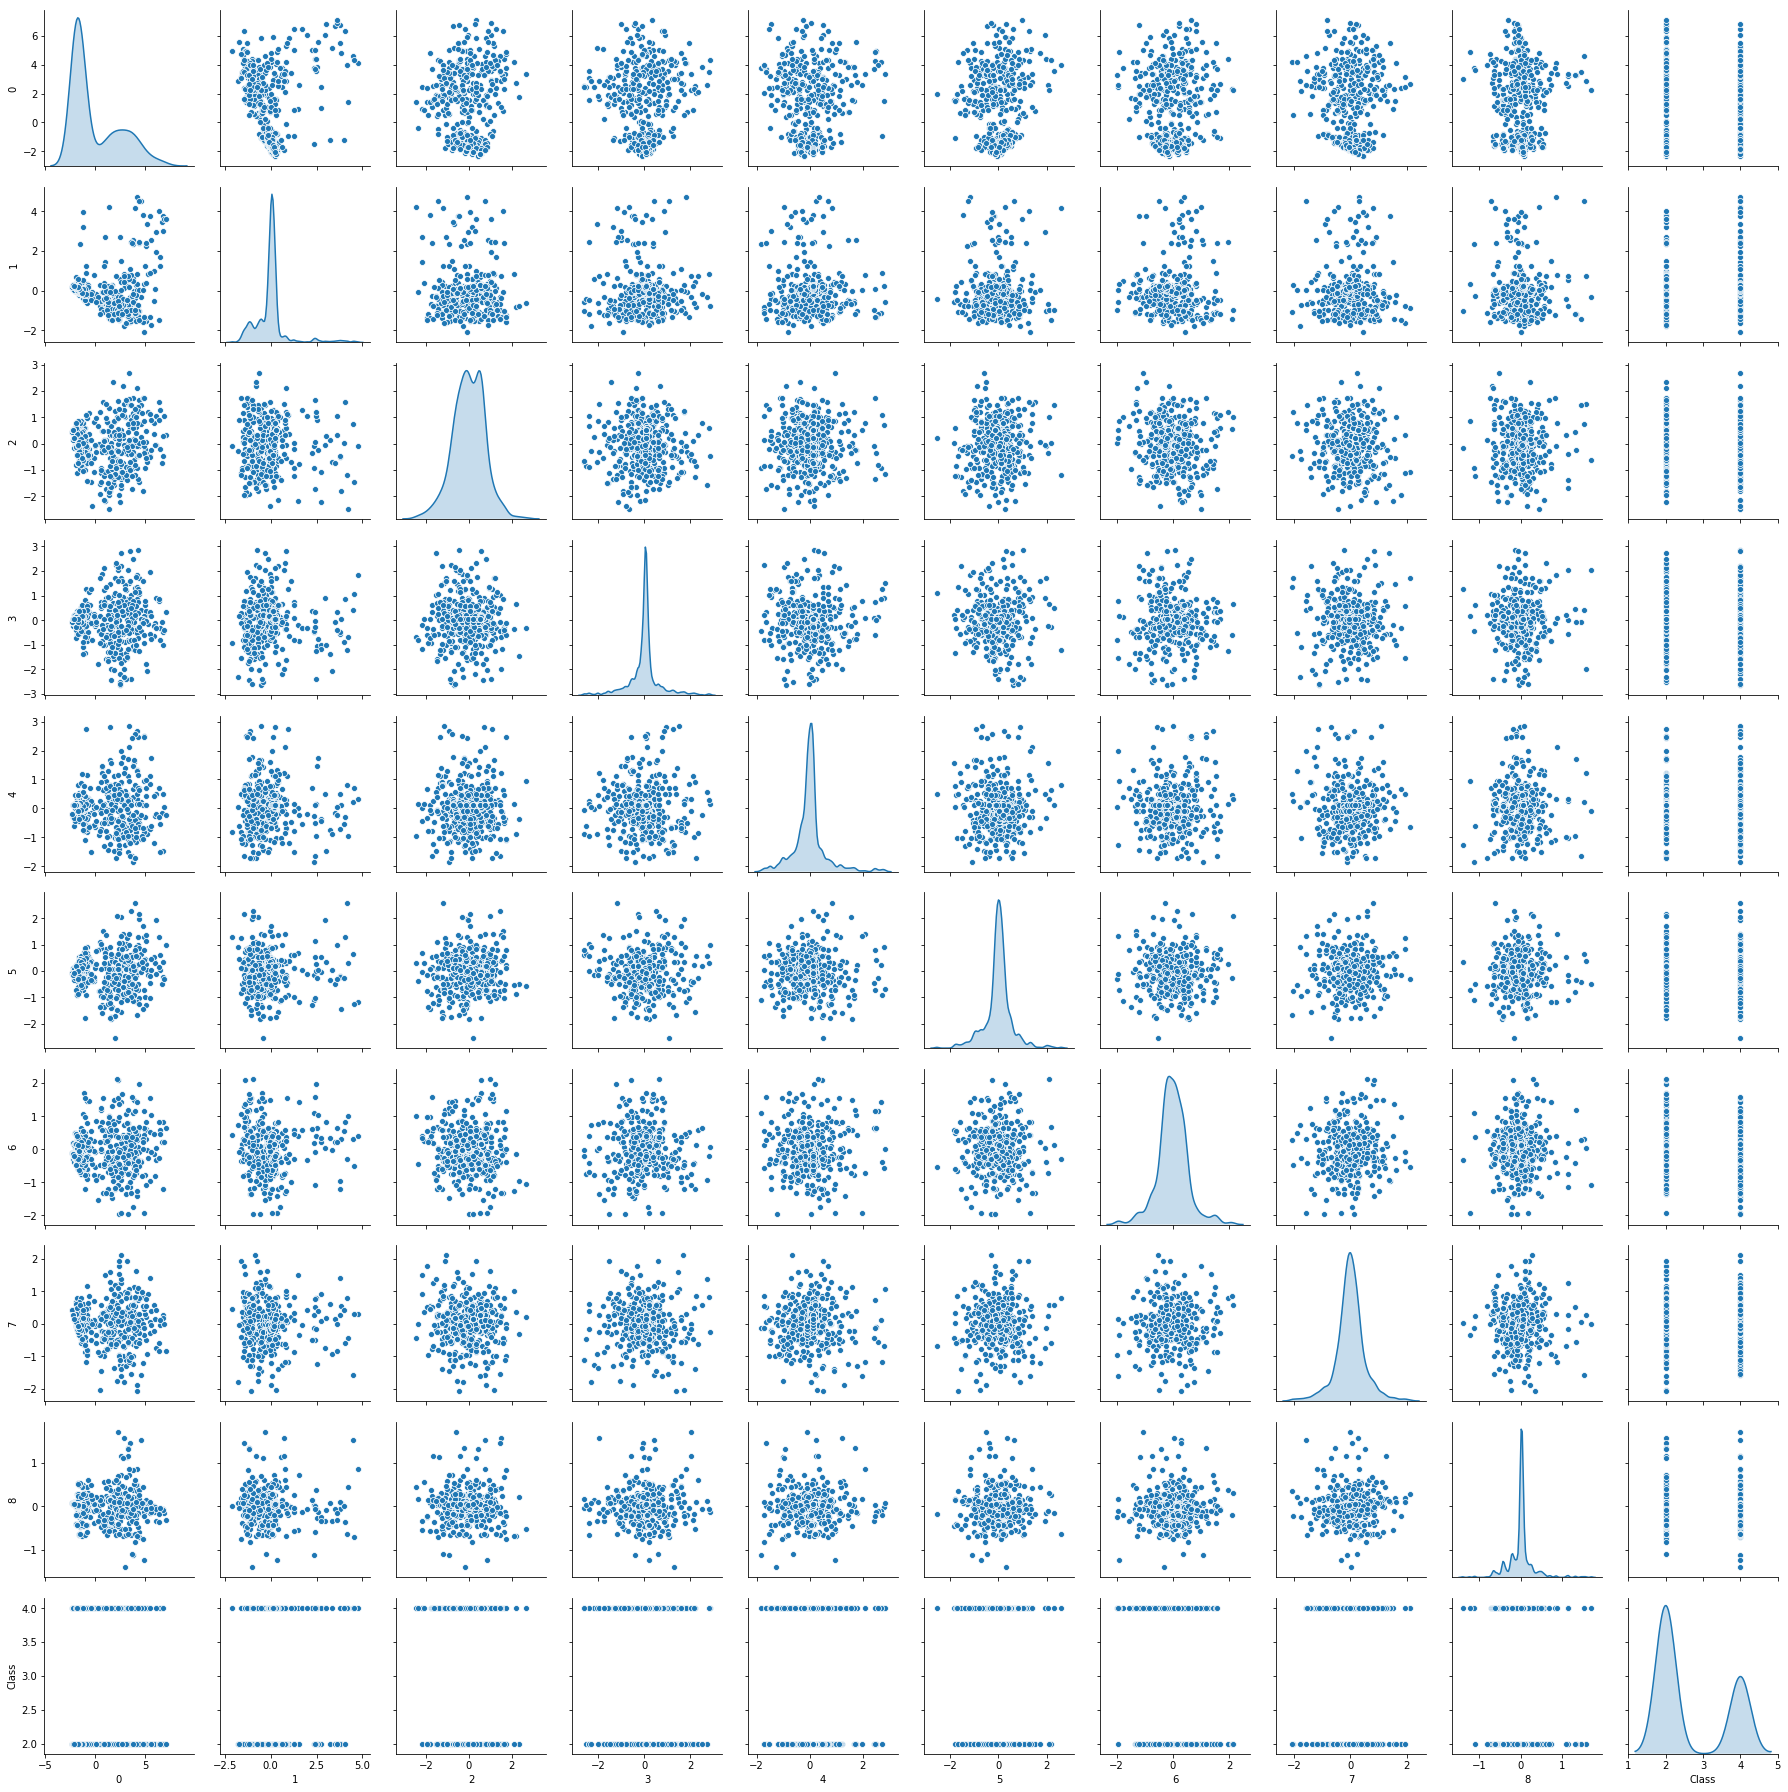

In [88]:
sns.pairplot(df_final, diag_kind='kde')

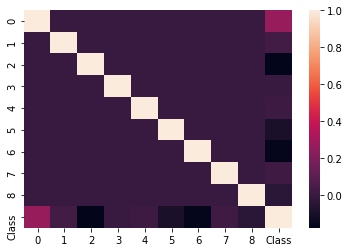

In [90]:
sns.heatmap(df_final.corr())

# Content Based Recommendation System - Optional ( Q11 - Q19 will not be graded)

# Q11 Read the Dataset `movies_metadata.csv`

# Q12 Create a new column with name 'description' combining `'overview' and 'tagline'` columns in the given dataset

# Q13  Lets drop the null values in `description` column

# Q14 Keep the first occurance and drop duplicates of each title in column `title`

# Q15   As we might have dropped a few rows with duplicate `title` in above step, just reset the index [make sure you are not adding any new column to the dataframe while doing reset index]

# Q16    Generate tf-idf matrix using the column `description`. Consider till 3-grams, with minimum document frequency as 0.

Hint:
tf = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=0, stop_words='english')

# Q17  Create cosine similarity matrix

# Q18  Write a function with name `recommend` which takes `title` as argument and returns a list of 10 recommended title names in the output based on the above cosine similarities

Hint:

titles = df['title'] <br>
indices = pd.Series(df.index, index=df['title']) <br>

def recommend(title): <br>
    idx = indices[title] <br>
    sim_scores = list(enumerate(cosine_similarities[idx])) <br>
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True) <br>
    sim_scores = sim_scores[1:31] <br>
    movie_indices = [i[0] for i in sim_scores] <br>
    return titles.iloc[movie_indices] <br>

# Q19 Give the recommendations from above functions for movies `The Godfather` and `The Dark Knight Rises`

# Popularity Based Recommendation System

### About Dataset

Anonymous Ratings on jokes.

1. Ratings are real values ranging from -10.00 to +10.00 (the value "99" corresponds to "null" = "not rated").

2. One row per user

3. The first column gives the number of jokes rated by that user. The next 100 columns give the ratings for jokes 01 - 100.

# Q20 Read the dataset(jokes.csv)

Take care about the header in read_csv() as there are no column names given in the dataset. 

# Q21 Consider `ratings` named dataframe with only first 200 rows and all columns from 1(first column is 0) of dataset

# Q22 Change the column indices from 0 to 99

# Q23 In the dataset, the null ratings are given as 99.00, so replace all 99.00s with 0
Hint: You can use `ratings.replace(<the given value>, <new value you wanted to change with>)`

# Q24 Normalize the ratings using StandardScaler and save them in `ratings_diff` variable

### Popularity based recommendation system

# Q25  Find the mean for each column  in `ratings_diff` i.e, for each joke
Consider all the mean ratings and find the jokes with highest mean value and display the top 10 joke IDs.